Scenario A — App Review Analysis: A product team analyzes their app's reviews on the App Store to understand user satisfaction. The average rating is 4.3/5, so they conclude that most users are happy. They plan to reduce investment in customer support.

Bias Type: Selection bias (specifically, voluntary response bias)
Explanation: The analysis only considers users who leave reviews, which tend to be people with very strong opinions—either very positive or very negative. Most silent users, who might be moderately satisfied or dissatisfied, are not represented. This inflates the apparent satisfaction level and could mislead the team into underinvesting in customer support.
Fix: Collect a random sample of users and solicit feedback through in-app surveys or emails, ensuring that all types of users—including silent ones—are represented.

Scenario B — Startup Success Study: A business school studies 200 successful tech startups (all founded in the last 10 years and still operating) to identify common traits that predict startup success. They find that 80% had a pivot in their first two years and conclude that pivoting is a key success strategy.


Bias Type: Survivorship Bias.
The study only looks at "survivors" (startups still operating), completely ignoring the thousands of failed companies that may have also pivoted but didn't survive. This distorts the conclusion by suggesting pivoting is a "secret sauce" for success, when in reality, it might be just as common among companies that went bankrupt.

Concrete Fix: Expand the dataset to include failed startups from the same period to determine if pivoting actually distinguishes winners from losers.

Scenario C — Health Survey: A health organization sends a voluntary online survey to 50,000 email subscribers asking about exercise habits and health outcomes. The survey receives 5,000 responses (10% response rate). Results show that respondents exercise an average of 5 hours per week and have excellent self-reported health.


Bias Type: Response Bias (and Self-Reporting Bias).
With only a 10% response rate, it is highly likely that people who are health-conscious and exercise regularly were more motivated to complete the survey than those who do not. This distorts the findings by overestimating the average health and activity levels of the entire 50,000-person subscriber base.

Concrete Fix: Conduct a follow-up study on a random sample of non-respondents or offer incentives to increase the response rate and capture a more diverse range of lifestyles.

Scenario D — Salary Benchmarking: A recruiting platform publishes average salaries by job title based on user-submitted salary data. The platform is popular among tech workers in large cities. A company in a small town uses this data to set their salary bands.

Bias Type: Selection bias / non-representative sampling
Explanation: The data mainly comes from tech workers in large cities, which is not representative of workers in smaller towns or different industries. Using this data to set salary bands in a small-town company will likely overestimate fair compensation.
Fix: Collect local salary data or adjust the existing data using geographic and industry-specific factors to reflect local market conditions.

Task 2: Create the population 

In [10]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 




In [11]:
np.random.seed(42)

In [12]:
population_size = 100_000
age = np.clip(np.random.normal(loc=40, scale=15, size=population_size), 18, 85).astype(int)

income = 1500 * age + np.random.normal(0, 30_000, population_size)
income = np.clip(income, 15_000, 250_000).astype(int)

satisfaction = 1 + (income - income.min()) / (income.max() - income.min()) * 9
satisfaction += np.random.normal(0, 2, population_size)  # add noise
satisfaction = np.clip(satisfaction, 1, 10)

regions = np.random.choice(['Urban', 'Suburban', 'Rural'], size=population_size, p=[0.6, 0.25, 0.15])


In [13]:
population = pd.DataFrame({
    'age' : age, 
    'income' : income, 
    'satisfaction' : satisfaction, 
    'region' : regions
})
population

,age,income,satisfaction,region
0,47,101417,7.874365,Suburban
1,37,20839,1.064969,Urban
2,49,90763,1.629206,Urban
3,62,74422,1.000000,Urban
4,36,44177,1.581043,Rural
...,...,...,...,...
99995,36,16063,1.000000,Urban
99996,31,63469,1.728727,Suburban
99997,46,73800,2.192770,Suburban
99998,36,79670,1.662634,Suburban


In [14]:
mean_age = population['age'].mean()
mean_income = population['income'].mean()
mean_satisfaction = population['satisfaction'].mean()
region_proportions = population['region'].value_counts(normalize=True)

In [15]:
print("Population Summary:")
print(f"Mean age: {mean_age:.2f}")
print(f"Mean income: ${mean_income:,.0f}")
print(f"Mean satisfaction: {mean_satisfaction:.2f}")
print("Region proportions:")
print(region_proportions)


Population Summary:
Mean age: 40.02
Mean income: $61,929
Mean satisfaction: 3.31
Region proportions:
region
Urban       0.59927
Suburban    0.25075
Rural       0.14998
Name: proportion, dtype: float64


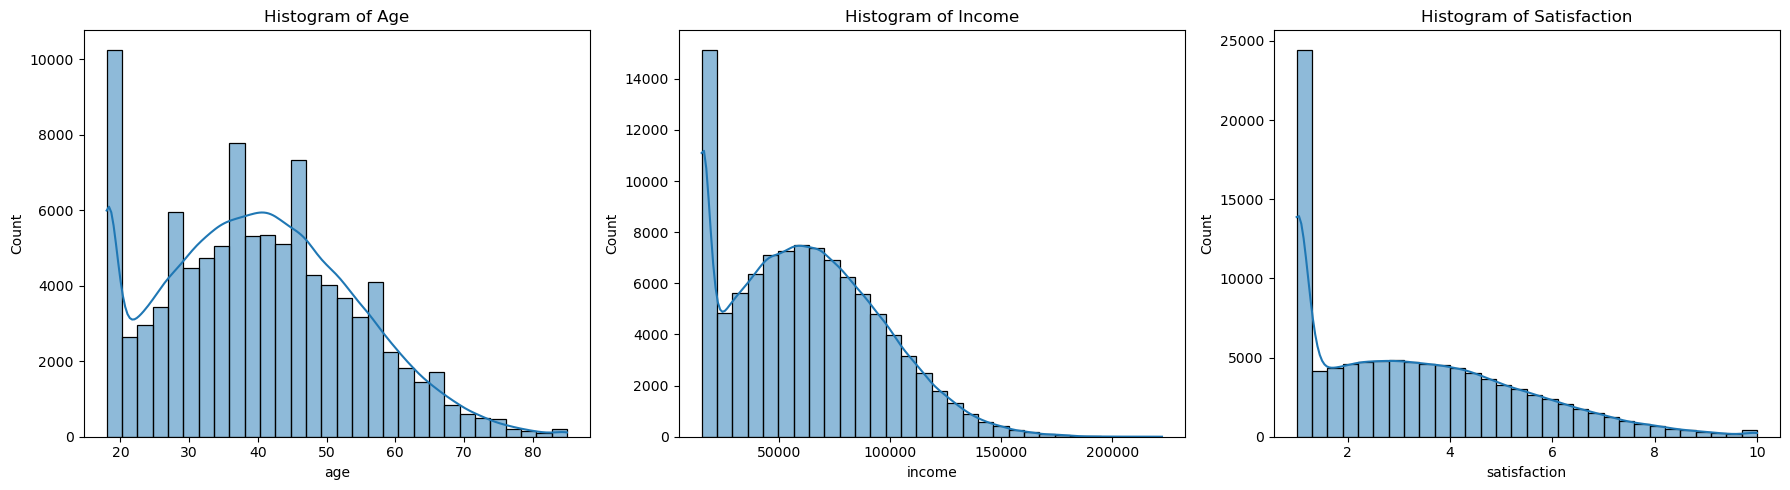

In [16]:
# --- Step 3: Plot histograms ---
numeric_vars = ['age', 'income', 'satisfaction']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, var in enumerate(numeric_vars):
    sns.histplot(population[var], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Histogram of {var.capitalize()}")
plt.tight_layout()
plt.show()

Task 3: Biased vs. Unbiased Sampling

In [17]:
#Simple random sample (n = 200): every individual has an equal chance of being selected.

sample_size = 200
srs = population.sample(n=sample_size, random_state=42)

In [18]:
#Biased sample — Urban only (n = 200): only sample from individuals in the "Urban" region

urban_only = population[population['region']=='Urban'].sample(n=sample_size, random_state=42)

In [20]:
#Biased sample — High-income filter (n = 200): only sample from individuals with income above the population median.
income_median = population['income'].median()
high_income_only = population[population['income'] > income_median].sample(n=sample_size, random_state=42)


In [21]:
def compute_means(df):
    return {
        'mean_age': df['age'].mean(),
        'mean_income': df['income'].mean(),
        'mean_satisfaction': df['satisfaction'].mean()
    }

In [22]:
summary_table = pd.DataFrame([
    compute_means(population),  # population
    compute_means(srs),
    compute_means(urban_only),
    compute_means(high_income_only)
], index=['Population', 'SRS', 'Urban Only', 'High-Income Only'])
print("Comparison of sample means:")
print(summary_table)


Comparison of sample means:
                  mean_age  mean_income  mean_satisfaction
Population        40.02052  61929.18132           3.305365
SRS               40.29000  64235.84000           3.355101
Urban Only        39.70000  62070.76000           3.405448
High-Income Only  46.74500  88226.01500           4.411648


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


<Figure size 640x480 with 0 Axes>

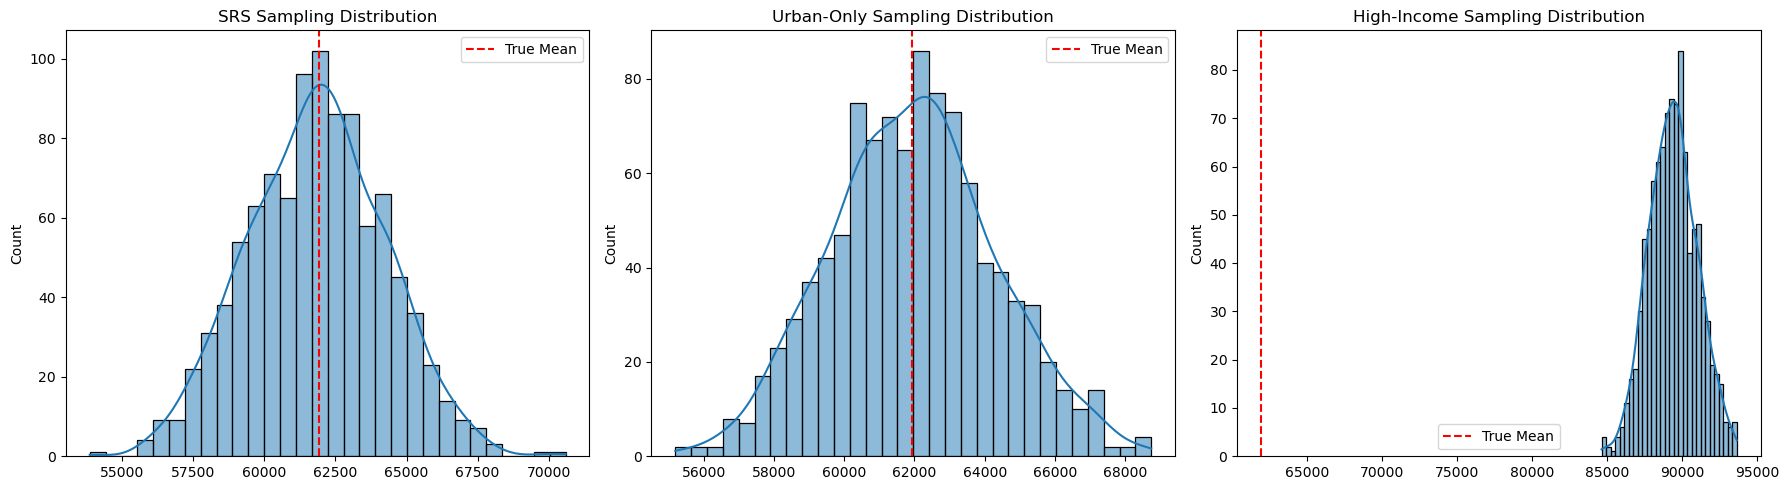

In [23]:
sns.kdeplot(population['income'], label='Population', ax=axes[0])
sns.kdeplot(srs['income'], label='SRS', ax=axes[0])
sns.kdeplot(urban_only['income'], label='Urban Only', ax=axes[0])
sns.kdeplot(high_income_only['income'], label='High-Income Only', ax=axes[0])
axes[0].set_title('Income Distribution Comparison')
axes[0].legend()

sns.kdeplot(population['satisfaction'], label='Population', ax=axes[1])
sns.kdeplot(srs['satisfaction'], label='SRS', ax=axes[1])
sns.kdeplot(urban_only['satisfaction'], label='Urban Only', ax=axes[1])
sns.kdeplot(high_income_only['satisfaction'], label='High-Income Only', ax=axes[1])
axes[1].set_title('Satisfaction Distribution Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Step 5: Repeat sampling 1,000 times for mean income ---
n_repeats = 1000

def sample_means(df_subset, size=sample_size, n_repeats=n_repeats):
    means = []
    for _ in range(n_repeats):
        sample = df_subset.sample(n=size)
        means.append(sample['income'].mean())
    return means

srs_means = sample_means(population)
urban_means = sample_means(population[population['region'] == 'Urban'])
high_income_means = sample_means(population[population['income'] > income_median])

# --- Step 6: Plot sampling distributions ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(srs_means, bins=30, kde=True, ax=axes[0])
axes[0].axvline(population['income'].mean(), color='red', linestyle='--', label='True Mean')
axes[0].set_title('SRS Sampling Distribution')
axes[0].legend()

sns.histplot(urban_means, bins=30, kde=True, ax=axes[1])
axes[1].axvline(population['income'].mean(), color='red', linestyle='--', label='True Mean')
axes[1].set_title('Urban-Only Sampling Distribution')
axes[1].legend()

sns.histplot(high_income_means, bins=30, kde=True, ax=axes[2])
axes[2].axvline(population['income'].mean(), color='red', linestyle='--', label='True Mean')
axes[2].set_title('High-Income Sampling Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

Analysis / Guiding Question

Simple Random Sample (SRS):

Sample means are centered closely around the population mean.

The KDE and repeated sampling distributions show unbiased estimates.

Urban-Only Sample:

Sample means are slightly higher for income and satisfaction (if urban residents earn more).

The distribution of repeated sample means is shifted away from the true population mean → biased estimate.

High-Income Only Sample:

Sample means are much higher for income and slightly higher for satisfaction.

The sampling distribution is heavily shifted → strongly biased estimate.

Conclusion:

Biased sampling strategies produce estimates systematically above or below the population mean.

SRS is unbiased because every individual has an equal chance of selection.

The shift of the sampling distribution relative to the population mean visually confirms the bias.